In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
from scipy.stats import norm
from scipy.optimize import minimize
from copy import deepcopy
from sklearn.linear_model import LinearRegression
import torch
import torch.nn as nn
#import scipy linear regression
import statsmodels.api as sm
from scipy.stats import t as t_dist
from scipy.stats import ttest_ind

In [18]:
#consider the cross
def consider_cross(label,feature,optimal_cost,true_tao_dict):
    K = feature.shape[1] - 1

    mapping_matrix = {}
    for i in range(1,feature.shape[1]):
        for j in range(i,feature.shape[1]):
            if i == j: 
                mapping_matrix[(i,i)] = i
            elif i<= 2:
                mapping_matrix[(i,j)] = 5 + (i - 1)*(6 - i) + j - i
            elif i == 3:
                mapping_matrix[(i,j)] = 12 + j - i
            else:
                mapping_matrix[(i,j)] = 15

    feature1 = np.zeros((feature.shape[0],feature.shape[1]+10))
    feature1[:,0] = 1
    for i in range(feature.shape[0]):
        for j1 in range(1,feature.shape[1]):
            for j2 in range(j1,feature.shape[1]):
                idx = mapping_matrix[(j1,j2)]
                feature1[i,idx] = feature[i,j1]*feature[i,j2]

    model = sm.OLS(label, feature1).fit()
    estimated_tao = model.params
    p_value = model.pvalues[1:]
    cov_matrix = model.cov_params()

    #estimated_variance = np.zeros(feature1.shape[1] - 1)
    #for i in range(feature1.shape[1] - 1):
        #estimated_variance[i] = cov_matrix[i+1,i+1]
    #estimated_variance = np.sum((label - feature@estimated_tao)**2)/(N)*np.linalg.inv(feature.T@feature)

    hat_ATE = estimated_tao[1:]
    estimated_tao_matrix = np.zeros((K,K))
    for i in range(1,K+1):
        for j in range(i,K+1):
            idx = mapping_matrix[(i,j)]
            if p_value[idx - 1] < 0.05:
                if i==j:
                    estimated_tao_matrix[i-1,i-1] = hat_ATE[idx-1]
                else:
                    estimated_tao_matrix[i-1,j-1] = hat_ATE[idx-1]/2
                    estimated_tao_matrix[j-1,i-1] = hat_ATE[idx-1]/2
            else:
                estimated_tao_matrix[i-1,j-1] = 0
                estimated_tao_matrix[j-1,i-1] = 0
    
    max_value = -100
    key_max = 0
    for i in range(2**K):
        key = tuple((i>>j)&1 for j in range(K))
        temp_tao = 0
        for m in range(K):
            for n in range(K):
                temp_tao += key[m]*key[n]*estimated_tao_matrix[m,n]
        if temp_tao > max_value:
            max_value = temp_tao
            key_max = key
        
        
    #estimated cost
    if optimal_cost == 0:
        if true_tao_dict[key_max] == 0:
            return 1
        else:
            return 0
    else:
        return true_tao_dict[key_max]/optimal_cost

### 1, design the data generating process (DGP)

$Y = a_0 + \tau_1t_1 + \tau_2t_2 + \tau_3t_3 + \tau_4t_4 + \tau_5t_5 - \sum_{i = 1}^5\sum_{j = i + 1}^5\tau_{i,j}t_i t_j$

In [8]:
# parameters setting
# we first assume \tau_6 = \tau_7 = 0. we have the only one paeameter.
K = 5
T = 10000
N = 5
Z = t_dist.ppf(0.975,N)
std_niose = 5
#anchor_set = [1]

tau_cross_set = [0,0.5,1,1.5,2,2.5,3]

cost = np.zeros((len(tau_cross_set),3,T))
for idx,tau_cross in enumerate(tau_cross_set):
    for t in tqdm(range(T)):
        true_tao = np.random.normal(1, 3, K )
        constant = np.random.normal(1, 3)
        #true_tao = np.array([1,2,-1])

        true_tao_maxtrix = np.zeros((K,K))
        for i in range(K):
            for j in range(i,K):
                if i != j:
                    temp_value = np.random.normal(tau_cross,1)
                    true_tao_maxtrix[i,j] = -temp_value/2
                    true_tao_maxtrix[j,i] = -temp_value/2
                else:
                    true_tao_maxtrix[i,j] = true_tao[i]
 

        true_tao_dict = {}
        #write a loop to generate the true_tao_dict, the key is the three dimension vector which the element is 0 or 1
        for i in range(2**K):
            key = tuple((i>>j)&1 for j in range(K))
            temp_tao = 0
            for m in range(K):
                for n in range(K):
                    temp_tao += key[m]*key[n]*true_tao_maxtrix[m,n]
            true_tao_dict[key] = temp_tao
            
        

        #obtain the max vlaue of the dict
        optimal_cost = max(true_tao_dict.values())



        # generate data
        feature = np.ones((N+K, K+1)) 
        #for index,key in enumerate(true_tao_dict.keys()):
            #feature[2*index, 1:] = np.array(key)
            #feature[2*index+1, 1:] = np.array(key)
            
        feature[:, 1:] = np.random.binomial(1, 0.5, (N+K,K))

        # generate label
        temp_label = np.zeros(N+K)
        for i in range(K):
            for j in range(K):
                temp_label += feature[:,i+1]*feature[:,j+1]*true_tao_maxtrix[i,j]
        label = constant + temp_label + np.random.normal(0, std_niose, N+K)

        #estimated tao
        model = sm.OLS(label, feature).fit()
        estimated_tao = model.params
        p_value = model.pvalues[1:]
        cov_matrix = model.cov_params()

        estimated_variance = np.zeros(K)
        for i in range(K):
            estimated_variance[i] = cov_matrix[i+1,i+1]
        #estimated_variance = np.sum((label - feature@estimated_tao)**2)/(N)*np.linalg.inv(feature.T@feature)

        hat_ATE = estimated_tao[1:]

        
        #estimated cost
        decision1 = np.argwhere(hat_ATE>(Z*np.sqrt(estimated_variance)))
        if optimal_cost == 0:
            if len(decision1) == 0:
                cost[idx,0,t] = 1
            else:
                cost[idx,0,t] = 0
        else:
            index = [0,0,0,0,0]
            if decision1.shape[0] != 0:
                for i in decision1:
                    index[i[0]] = 1
            cost[idx,0,t] = true_tao_dict[tuple(index)]/optimal_cost
        tau_0 = np.mean(hat_ATE)

        
        
        if tau_0 == 0:
            cost[idx,1,t] = cost[idx,0,t]
            continue
        beta = N*np.mean(estimated_variance)/(np.var(hat_ATE) - np.mean(estimated_variance)) +  Z*N*np.sqrt(np.mean(estimated_variance))/tau_0
        beta = max(0,beta)
        theta = N/(N+beta)
        shrunken_ATE = theta*hat_ATE + (1-theta)*tau_0
        decision2 = np.argwhere(shrunken_ATE>(theta*Z*np.sqrt(estimated_variance))/np.sqrt(N))

        if optimal_cost == 0:
            if len(decision2) == 0:
                cost[idx,1,t] = 1
            else:
                cost[idx,1,t] = 0
        else:
            index = [0,0,0,0,0]
            if len(decision2) != 0:
                for i in decision2:
                    index[i[0]] = 1
            cost[idx,1,t] = true_tao_dict[tuple(index)]/optimal_cost
    
        #consider the cross
        #ost[idx,2,t] = consider_cross(label,feature,optimal_cost,true_tao_dict)
        bayesian_tao = np.zeros(K)
        bayesian_beta = np.zeros(K)
        denumerator = np.var(hat_ATE) - np.mean(estimated_variance)
        decision3 = []
  
        for k in range(K):
            if denumerator <= 0:
                theta = 1
                posteri_mean = hat_ATE[k]*theta + (1 - theta)*tau_0
                posteri_var = estimated_variance[k]
                if posteri_var == 0:
                    if posteri_mean > 0:
                        prob = 1
                    else:
                        prob = 0
                else:
                    dist = norm(loc=posteri_mean, scale=np.sqrt(posteri_var))
                    prob = dist.sf(0)  # survival function: P(X > x)
                if prob > 1 - 0.025:
                    decision3.append(k)
            else:
                bayesian_beta[k] = max(N*estimated_variance[k]/denumerator,0)
                theta = N/(N+bayesian_beta[k])
                posteri_mean = hat_ATE[k]*theta + (1 - theta)*tau_0
                posteri_var = (denumerator*estimated_variance[k])/(denumerator+ estimated_variance[k])
                if posteri_var == 0:
                    if posteri_mean > 0:
                        prob = 1
                    else:
                        prob = 0
                else:
                    dist = norm(loc=posteri_mean, scale=np.sqrt(posteri_var))
                    prob = dist.sf(0)  # survival function: P(X > x)
                if prob > 1 - 0.025:
                    decision3.append(k)
        if optimal_cost == 0:
            if len(decision3) == 0:
                cost[idx,2,t] = 1
            else:
                cost[idx,2,t] = 0
        else:
            index = [0,0,0,0,0]
            if len(decision3) != 0:
                for i in decision3:
                    index[i] = 1
            cost[idx,2,t] = true_tao_dict[tuple(index)]/optimal_cost

100%|██████████| 10000/10000 [00:11<00:00, 833.96it/s]


In [4]:
estimated_variance

array([115.79595284,  39.16627817,  44.27492315,  28.94898821,
        30.65186987])

In [10]:
np.save("cost_non_linear_test_10.npy",cost)

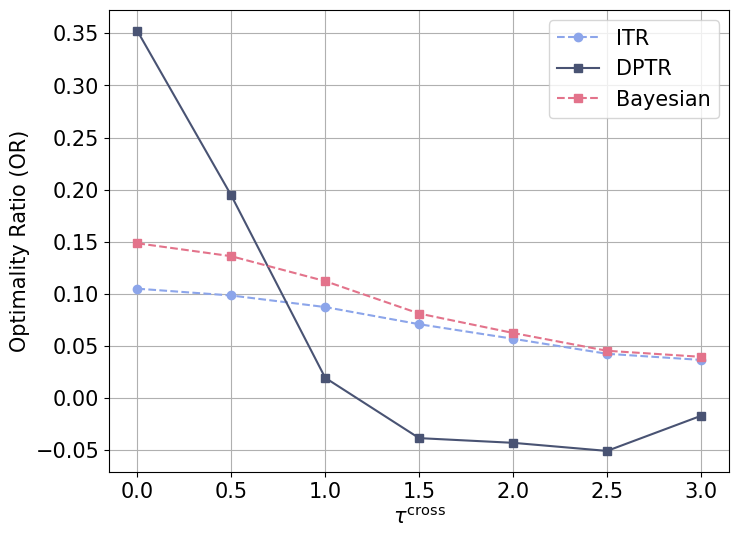

In [4]:
cost = np.load("cost_non_linear_test_10.npy")
tau_cross_set = [0,0.5,1,1.5,2,2.5,3]
plt.figure(figsize=(8,6))
plt.xlabel(r'$\tau^{\text{cross}}$',fontsize=15)
plt.ylabel('Optimality Ratio (OR)',fontsize=15)
x = tau_cross_set
y3 = np.mean(cost[:,0,:],axis=1)

    
plt.plot(x, y3, color = '#8CA5EA',linestyle = '--', marker='o',label = "ITR")


y3 = np.mean(cost[:,1,:],axis=1)
plt.plot(x, y3, color = '#495373',marker = "s",label = "DPTR")


y3 = np.mean(cost[:,2,:],axis=1)
plt.plot(x, y3, color = '#E3738B',marker = "s",label = "Bayesian",linestyle = '--')


plt.xticks(x,fontsize=15)
plt.yticks(fontsize=15)
plt.legend(fontsize=15)
plt.grid()
plt.savefig('scenario1_figures/N_10.png',dpi=300,bbox_inches = 'tight')
plt.show()